In [13]:
import os
import numpy as np
import rasterio
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

# config
DATASET_DIR   = "C:\\Users\\uceda\\Documents\\uni\\master\\ENLIGHT\\course\\data\\dataset\\s2\\200m"
TRAIN_LST     = "data/train_filenames.lst"
TEST_LST      = "data/test_filenames.lst"
CACHE_DIR     = "data/cache"          # where .npy files are saved
MAX_H, MAX_W  = 21, 21
NUM_CLASSES   = 20

species_list = [
    "Abies_alba", "Acer_pseudoplatanus", "Alnus_spec", "Betula_spec",
    "Cleared", "Fagus_sylvatica", "Fraxinus_excelsior", "Larix_decidua",
    "Larix_kaempferi", "Picea_abies", "Pinus_nigra", "Pinus_strobus",
    "Pinus_sylvestris", "Populus_spec", "Prunus_spec", "Pseudotsuga_menziesii",
    "Quercus_petraea", "Quercus_robur", "Quercus_rubra", "Tilia_spec",
]

os.makedirs(CACHE_DIR, exist_ok=True)

In [ ]:
# load filenames
with open(TRAIN_LST) as f:
    train_filenames = f.read().splitlines()
with open(TEST_LST) as f:
    test_filenames = f.read().splitlines()

print(f"Train: {len(train_filenames)} | Test: {len(test_filenames)}")

Train: 45337 | Test: 5044


In [ ]:
# extract one-hot label from filename
def filename_to_onehot(filename):
    vec = np.zeros(NUM_CLASSES, dtype=np.float32)
    for i, species in enumerate(species_list):
        if species in filename:
            vec[i] = 1.0
            break          # single-label; remove break for multi-label from filename
    return vec

# load and pad one .tif
def load_tif(filename):
    path = os.path.join(DATASET_DIR, filename)
    with rasterio.open(path) as src:
        img = src.read().astype(np.float32)      # (12, H, W)
    pad_h = MAX_H - img.shape[1]
    pad_w = MAX_W - img.shape[2]
    img = np.pad(img, ((0, 0), (0, pad_h), (0, pad_w)), mode='constant')
    return img.flatten()                          # (5292,)

# build or load cached arrays
def build_split(filenames, split_name):
    X_path = os.path.join(CACHE_DIR, f"X_{split_name}.npy")
    y_path = os.path.join(CACHE_DIR, f"y_{split_name}.npy")

    if os.path.exists(X_path) and os.path.exists(y_path):
        print(f"Loading cached {split_name} arrays...")
        X = np.load(X_path)
        y = np.load(y_path)
        return X, y

    print(f"Building {split_name} arrays from .tif files...")
    X_list, y_list = [], []
    for i, fn in enumerate(filenames):
        if i % 500 == 0:
            print(f"  {i}/{len(filenames)}")
        X_list.append(load_tif(fn))
        y_list.append(filename_to_onehot(fn))

    X = np.array(X_list, dtype=np.float32)   # (N, 5292)
    y = np.array(y_list, dtype=np.float32)   # (N, 20)

    np.save(X_path, X)
    np.save(y_path, y)
    print(f"  Saved to {X_path} and {y_path}")
    return X, y

In [12]:
X_train, y_train = build_split(train_filenames, "train")
X_test,  y_test  = build_split(test_filenames,  "test")

print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")


Building train arrays from .tif files...
  0/45337
  500/45337
  1000/45337
  1500/45337
  2000/45337
  2500/45337
  3000/45337
  3500/45337
  4000/45337
  4500/45337
  5000/45337
  5500/45337
  6000/45337
  6500/45337
  7000/45337
  7500/45337
  8000/45337
  8500/45337
  9000/45337
  9500/45337
  10000/45337
  10500/45337
  11000/45337
  11500/45337
  12000/45337
  12500/45337
  13000/45337
  13500/45337
  14000/45337
  14500/45337
  15000/45337
  15500/45337
  16000/45337
  16500/45337
  17000/45337
  17500/45337
  18000/45337
  18500/45337
  19000/45337
  19500/45337
  20000/45337
  20500/45337
  21000/45337
  21500/45337
  22000/45337
  22500/45337
  23000/45337
  23500/45337
  24000/45337
  24500/45337
  25000/45337
  25500/45337
  26000/45337
  26500/45337
  27000/45337
  27500/45337
  28000/45337
  28500/45337
  29000/45337
  29500/45337
  30000/45337
  30500/45337
  31000/45337
  31500/45337
  32000/45337
  32500/45337
  33000/45337
  33500/45337
  34000/45337
  34500/45337
  3

In [ ]:
import os
import numpy as np
import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn
from sklearn.metrics import recall_score, precision_score, f1_score, average_precision_score
import matplotlib.pyplot as plt

CACHE_DIR   = "data/cache"
MODEL_DIR   = "data/models"
os.makedirs(MODEL_DIR, exist_ok=True)

NUM_CLASSES = 20
EPOCHS      = 150
BATCH_SIZE  = 32
LR_MIN      = 0.00005
LR_MAX      = 0.001

# load cached arrays
print("Loading cached arrays...")
X_train = np.load(os.path.join(CACHE_DIR, "X_train.npy"))
y_train = np.load(os.path.join(CACHE_DIR, "y_train.npy"))
X_test  = np.load(os.path.join(CACHE_DIR, "X_test.npy"))
y_test  = np.load(os.path.join(CACHE_DIR, "y_test.npy"))
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")


Loading cached arrays...
X_train: (45337, 5292) | y_train: (45337, 20)
X_test:  (5044, 5292)  | y_test:  (5044, 20)


In [ ]:
# normalize
mean = X_train.mean(axis=0)
std  = X_train.std(axis=0) + 1e-8
X_train = (X_train - mean) / std
X_test  = (X_test  - mean) / std

In [ ]:
# tensors & dataloaders
X_train_t = torch.tensor(X_train)
y_train_t = torch.tensor(y_train)
X_test_t  = torch.tensor(X_test)
y_test_t  = torch.tensor(y_test)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test_t,  y_test_t),  batch_size=BATCH_SIZE, shuffle=False)

In [ ]:
# MLP (3 hidden layers, 512 units each)
class MLP(nn.Module):
    def __init__(self, in_dim=5292, hidden_dim=512, out_dim=NUM_CLASSES):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),  nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_dim),
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model  = MLP().to(device)
print(f"\nUsing device: {device}")


Using device: cpu


In [ ]:
# loss, optimizer, cyclic LR 
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LR_MIN)

# step_size_up = half cycle length; 4 cycles over 150 epochs is a common choice
scheduler = torch.optim.lr_scheduler.CyclicLR(
    optimizer,
    base_lr    = LR_MIN,
    max_lr     = LR_MAX,
    step_size_up = len(train_loader) * 4,   # cycle up over ~4 epochs
    mode       = "triangular",
    cycle_momentum = False,                  # Adam has no momentum param
)

In [ ]:
#metrics helper 
def compute_metrics(y_true, y_pred_prob, threshold=0.5):
    y_pred = (y_pred_prob >= threshold).astype(int)

    metrics = {}
    for avg in ("micro", "weighted"):
        metrics[f"precision_{avg}"] = precision_score(y_true, y_pred, average=avg, zero_division=0)
        metrics[f"recall_{avg}"]    = recall_score(   y_true, y_pred, average=avg, zero_division=0)
        metrics[f"f1_{avg}"]        = f1_score(       y_true, y_pred, average=avg, zero_division=0)
        metrics[f"mAP_{avg}"]       = average_precision_score(y_true, y_pred_prob, average=avg)
    return metrics

In [9]:
# training loop
history = {
    "train_loss": [], "test_loss": [],
    "f1_micro": [],   "f1_weighted": [],
    "mAP_micro": [],  "mAP_weighted": [],
}

for epoch in range(1, EPOCHS + 1):

    # train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        scheduler.step()
        train_loss += loss.item() * len(X_batch)
    train_loss /= len(train_loader.dataset)

    # eval
    model.eval()
    test_loss = 0.0
    all_probs, all_labels = [], []
    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            test_loss += criterion(logits, y_batch).item() * len(X_batch)
            all_probs.append(torch.sigmoid(logits).cpu().numpy())
            all_labels.append(y_batch.cpu().numpy())
    test_loss /= len(test_loader.dataset)

    y_prob = np.concatenate(all_probs,  axis=0)
    y_true = np.concatenate(all_labels, axis=0)
    m = compute_metrics(y_true, y_prob)

    history["train_loss"].append(train_loss)
    history["test_loss"].append(test_loss)
    history["f1_micro"].append(m["f1_micro"])
    history["f1_weighted"].append(m["f1_weighted"])
    history["mAP_micro"].append(m["mAP_micro"])
    history["mAP_weighted"].append(m["mAP_weighted"])

    if epoch % 10 == 0 or epoch == 1:
        print(f"Epoch {epoch:3d}/{EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f} | "
              f"F1 micro: {m['f1_micro']:.4f} | F1 weighted: {m['f1_weighted']:.4f} | "
              f"mAP micro: {m['mAP_micro']:.4f} | mAP weighted: {m['mAP_weighted']:.4f}")


Epoch   1/150 | Train Loss: 0.1596 | Test Loss: 0.1353 | F1 micro: 0.3110 | F1 weighted: 0.2629 | mAP micro: 0.4275 | mAP weighted: 0.4113
Epoch  10/150 | Train Loss: 0.0891 | Test Loss: 0.1173 | F1 micro: 0.4985 | F1 weighted: 0.4628 | mAP micro: 0.5654 | mAP weighted: 0.5477
Epoch  20/150 | Train Loss: 0.0850 | Test Loss: 0.1383 | F1 micro: 0.5032 | F1 weighted: 0.4643 | mAP micro: 0.5288 | mAP weighted: 0.5153
Epoch  30/150 | Train Loss: 0.0597 | Test Loss: 0.1640 | F1 micro: 0.5317 | F1 weighted: 0.5159 | mAP micro: 0.5499 | mAP weighted: 0.5361
Epoch  40/150 | Train Loss: 0.0248 | Test Loss: 0.2347 | F1 micro: 0.5528 | F1 weighted: 0.5390 | mAP micro: 0.5665 | mAP weighted: 0.5488
Epoch  50/150 | Train Loss: 0.0290 | Test Loss: 0.2588 | F1 micro: 0.5216 | F1 weighted: 0.5135 | mAP micro: 0.5207 | mAP weighted: 0.5209
Epoch  60/150 | Train Loss: 0.0561 | Test Loss: 0.2428 | F1 micro: 0.5003 | F1 weighted: 0.4760 | mAP micro: 0.5031 | mAP weighted: 0.4935
Epoch  70/150 | Train Loss:

In [10]:
# save model 
model_path = os.path.join(MODEL_DIR, "mlp_s2_200m.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "mean": mean,
    "std":  std,
}, model_path)
print(f"\nModel saved to {model_path}")


Model saved to data/models\mlp_s2_200m.pt


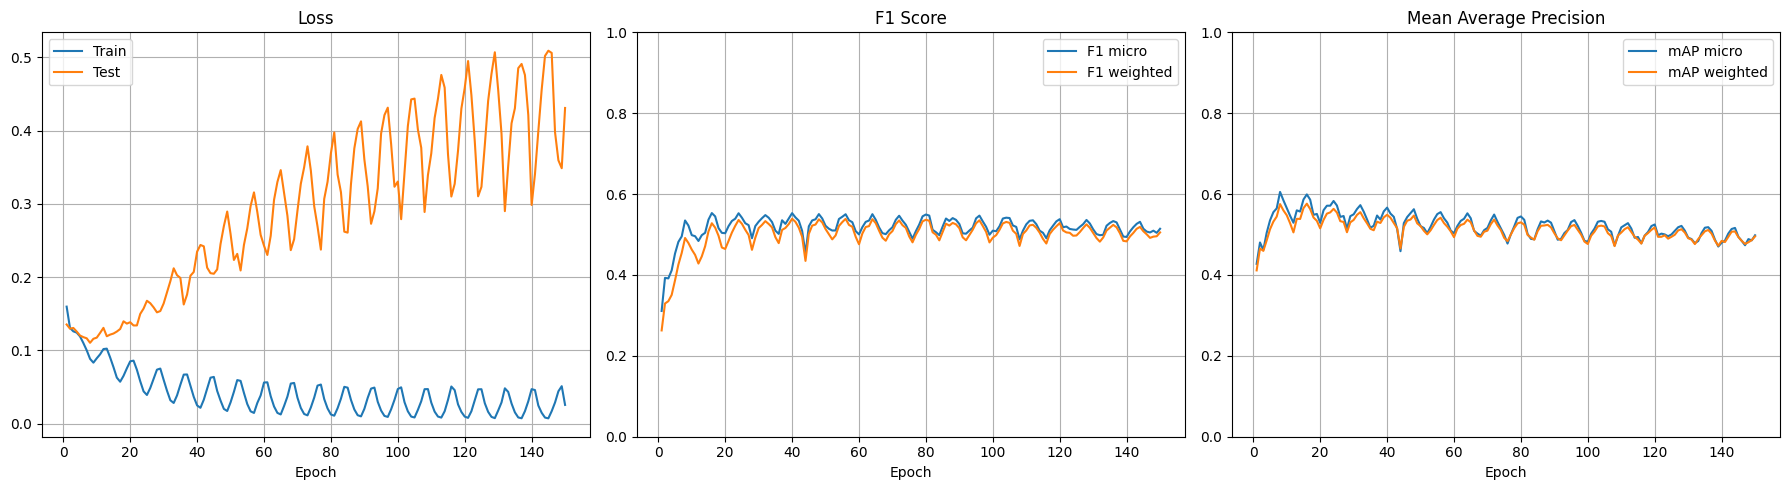

Plot saved to data/models\training_curves.png


In [11]:
# plot
epochs_x = range(1, EPOCHS + 1)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(epochs_x, history["train_loss"], label="Train")
axes[0].plot(epochs_x, history["test_loss"],  label="Test")
axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch")
axes[0].legend(); axes[0].grid(True)

axes[1].plot(epochs_x, history["f1_micro"],    label="F1 micro")
axes[1].plot(epochs_x, history["f1_weighted"], label="F1 weighted")
axes[1].set_title("F1 Score"); axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True)

axes[2].plot(epochs_x, history["mAP_micro"],    label="mAP micro")
axes[2].plot(epochs_x, history["mAP_weighted"], label="mAP weighted")
axes[2].set_title("Mean Average Precision"); axes[2].set_xlabel("Epoch")
axes[2].set_ylim(0, 1); axes[2].legend(); axes[2].grid(True)

plt.tight_layout()
plot_path = os.path.join(MODEL_DIR, "training_curves.png")
plt.savefig(plot_path, dpi=150)
plt.show()
print(f"Plot saved to {plot_path}")

In [14]:
# final evaluation
model.eval()
all_probs, all_labels = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        all_probs.append(torch.sigmoid(model(X_batch)).cpu().numpy())
        all_labels.append(y_batch.numpy())

y_prob = np.concatenate(all_probs,  axis=0)   # (N_test, 20)
y_true = np.concatenate(all_labels, axis=0)   # (N_test, 20)
y_pred = (y_prob >= 0.5).astype(int)

# per-class metrics
per_class = {}
for i, species in enumerate(species_list):
    per_class[species] = {
        "precision": precision_score(y_true[:, i], y_pred[:, i], zero_division=0),
        "recall":    recall_score(   y_true[:, i], y_pred[:, i], zero_division=0),
        "f1":        f1_score(       y_true[:, i], y_pred[:, i], zero_division=0),
        "AP":        average_precision_score(y_true[:, i], y_prob[:, i]),
        "support":   int(y_true[:, i].sum()),
    }

# aggregate: micro + weighted
results = {}
for avg in ("micro", "weighted"):
    results[avg] = {
        "precision": precision_score(y_true, y_pred, average=avg, zero_division=0),
        "recall":    recall_score(   y_true, y_pred, average=avg, zero_division=0),
        "f1":        f1_score(       y_true, y_pred, average=avg, zero_division=0),
        "mAP":       average_precision_score(y_true, y_prob, average=avg),
    }

# print summary table
print("\n" + "="*75)
print(f"{'FINAL TEST EVALUATION':^75}")
print("="*75)
print(f"\n{'Metric':<15} {'Micro':>12} {'Weighted':>12}")
print("-"*40)
for metric in ("precision", "recall", "f1", "mAP"):
    print(f"{metric:<15} {results['micro'][metric]:>12.4f} {results['weighted'][metric]:>12.4f}")

# print per-class table 
print(f"\n{'Per-class breakdown':^75}")
print("-"*75)
print(f"{'Species':<30} {'Precision':>10} {'Recall':>10} {'F1':>10} {'AP':>10} {'Support':>8}")
print("-"*75)
for species, m in sorted(per_class.items(), key=lambda x: -x[1]["support"]):
    print(f"{species:<30} {m['precision']:>10.4f} {m['recall']:>10.4f} "
          f"{m['f1']:>10.4f} {m['AP']:>10.4f} {m['support']:>8d}")
print("="*75)


                           FINAL TEST EVALUATION                           

Metric                 Micro     Weighted
----------------------------------------
precision             0.5687       0.5600
recall                0.4693       0.4693
f1                    0.5142       0.5053
mAP                   0.4982       0.4954

                            Per-class breakdown                            
---------------------------------------------------------------------------
Species                         Precision     Recall         F1         AP  Support
---------------------------------------------------------------------------
Pinus_sylvestris                   0.7445     0.7124     0.7281     0.7887      671
Fagus_sylvatica                    0.6782     0.5837     0.6274     0.6552      639
Picea_abies                        0.7162     0.6585     0.6861     0.6796      571
Cleared                            0.6939     0.6445     0.6683     0.6626      422
Quercus_robur         